In [1]:
# ============================================================
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================

# Dataset
DATA_PATH = r"D:\Real-Time-Financial-Fraud-Detection-Pipeline-\data\PS_20174392719_1491204439457_log.csv"
MAX_ROWS = 500_000

# Reproducibility
RANDOM_STATE = 42

# Data split
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.25

# Selected Isolation Forest configuration
N_ESTIMATORS = 500
MAX_SAMPLES = 0.5
MAX_FEATURES = 1.0
CONTAMINATION = "auto"
BOOTSTRAP = False
N_JOBS = -1

# Threshold analysis
THRESHOLD_POINTS = 1000
THRESHOLD_LOW_PERCENTILE = 50.0
THRESHOLD_HIGH_PERCENTILE = 99.9

# Recall targets
RECALL_TARGETS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

# Output directories
RESULT_DIR = Path("results") / "false_negative_analysis"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Basic path check
print("Configuration loaded successfully.")
print(f"Dataset path: {DATA_PATH}")
print(f"Dataset exists: {Path(DATA_PATH).exists()}")
print(f"Maximum rows: {MAX_ROWS:,}")
print(f"Random state: {RANDOM_STATE}")
print(f"Trees: {N_ESTIMATORS}")
print(f"Max samples: {MAX_SAMPLES}")
print(f"Max features: {MAX_FEATURES}")
print(f"Threshold points: {THRESHOLD_POINTS}")
print(f"Recall targets: {RECALL_TARGETS}")

Configuration loaded successfully.
Dataset path: D:\Real-Time-Financial-Fraud-Detection-Pipeline-\data\PS_20174392719_1491204439457_log.csv
Dataset exists: True
Maximum rows: 500,000
Random state: 42
Trees: 500
Max samples: 0.5
Max features: 1.0
Threshold points: 1000
Recall targets: [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]


In [3]:
# ============================================================
# BLOCK 3 — LOAD PAYSIM DATASET
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    nrows=MAX_ROWS
)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape: (500000, 11)

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# ============================================================
# BLOCK 4 — DATA QUALITY & FRAUD DISTRIBUTION
# ============================================================

print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset information:")
df.info()

print("\nTransaction type distribution:")
display(df["type"].value_counts())

print("\nFraud distribution:")
fraud_counts = df["isFraud"].value_counts()

display(
    pd.DataFrame({
        "count": fraud_counts,
        "percentage": fraud_counts / len(df) * 100
    })
)

print("\nFraud rate:")
print(f"{df['isFraud'].mean() * 100:.4f}%")

Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicate rows:
0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            500000 non-null  int64  
 1   type            500000 non-null  object 
 2   amount          500000 non-null  float64
 3   nameOrig        500000 non-null  object 
 4   oldbalanceOrg   500000 non-null  float64
 5   newbalanceOrig  500000 non-null  float64
 6   nameDest        500000 non-null  object 
 7   oldbalanceDest  500000 non-null  float64
 8   newbalanceDest  500000 non-null  float64
 9   isFraud         500000 non-null  int64  
 10  isFlaggedFraud  500000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 42.0+ MB

Transaction type distribution:


type
CASH_OUT    182316
PAYMENT     164032
CASH_IN     109319
TRANSFER     40730
DEBIT         3603
Name: count, dtype: int64


Fraud distribution:


,count,percentage
isFraud,,
0,499767,99.9534
1,233,0.0466



Fraud rate:
0.0466%


In [5]:
# ============================================================
# BLOCK 5 — FEATURE ENGINEERING
# ============================================================

work = df.copy()

# ------------------------------------------------------------
# 1. Origin account balance movement
# ------------------------------------------------------------
work["orig_balance_change"] = (
    work["oldbalanceOrg"] - work["newbalanceOrig"]
)

# ------------------------------------------------------------
# 2. Destination account balance movement
# ------------------------------------------------------------
work["dest_balance_change"] = (
    work["newbalanceDest"] - work["oldbalanceDest"]
)

# ------------------------------------------------------------
# 3. Origin balance consistency error
# ------------------------------------------------------------
work["orig_balance_error"] = (
    work["amount"] - work["orig_balance_change"]
)

# ------------------------------------------------------------
# 4. Destination balance consistency error
# ------------------------------------------------------------
work["dest_balance_error"] = (
    work["amount"] - work["dest_balance_change"]
)

# ------------------------------------------------------------
# 5. Origin balance becomes zero
# ------------------------------------------------------------
work["orig_zero_after"] = (
    work["newbalanceOrig"] == 0
).astype(int)

# ------------------------------------------------------------
# 6. Destination balance is zero before transaction
# ------------------------------------------------------------
work["dest_zero_before"] = (
    work["oldbalanceDest"] == 0
).astype(int)

# ------------------------------------------------------------
# 7. Destination balance becomes zero
# ------------------------------------------------------------
work["dest_zero_after"] = (
    work["newbalanceDest"] == 0
).astype(int)

# ------------------------------------------------------------
# 8. Log-transform transaction amount
# ------------------------------------------------------------
work["log_amount"] = np.log1p(work["amount"])

# ------------------------------------------------------------
# 9. One-hot encode transaction type
# ------------------------------------------------------------
work = pd.get_dummies(
    work,
    columns=["type"],
    prefix="type",
    dtype=int
)

# ------------------------------------------------------------
# 10. Exact feature order used by Isolation Forest
# ------------------------------------------------------------
feature_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error",
    "orig_zero_after",
    "dest_zero_before",
    "dest_zero_after",
    "log_amount",
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

# ------------------------------------------------------------
# 11. Build final feature matrix and target
# ------------------------------------------------------------
X = work[feature_columns].astype(np.float32)
y = work["isFraud"].astype(int)

print("Feature engineering completed.")
print(f"Feature matrix shape: {X.shape}")

print("\nFeature columns:")
for i, col in enumerate(feature_columns, start=1):
    print(f"{i:>2}. {col}")

print("\nNaN values:", int(X.isna().sum().sum()))
print("Infinite values:", int(np.isinf(X.to_numpy()).sum()))

Feature engineering completed.
Feature matrix shape: (500000, 19)

Feature columns:
 1. step
 2. amount
 3. oldbalanceOrg
 4. newbalanceOrig
 5. oldbalanceDest
 6. newbalanceDest
 7. orig_balance_change
 8. dest_balance_change
 9. orig_balance_error
10. dest_balance_error
11. orig_zero_after
12. dest_zero_before
13. dest_zero_after
14. log_amount
15. type_CASH_IN
16. type_CASH_OUT
17. type_DEBIT
18. type_PAYMENT
19. type_TRANSFER

NaN values: 0
Infinite values: 0


In [6]:
# ============================================================
# BLOCK 6 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# ------------------------------------------------------------
# 1. First split:
#    80% temporary data + 20% final test data
# ------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# 2. Second split:
#    Split the remaining 80% equally into:
#    60% final training + 20% validation
# ------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# 3. Keep only legitimate transactions for training
# ------------------------------------------------------------
X_train_normal = X_train[y_train == 0].copy()

# ------------------------------------------------------------
# 4. Display dataset sizes
# ------------------------------------------------------------
print("Data split completed.\n")

print(f"Total dataset       : {len(X):,}")
print(f"Training set        : {len(X_train):,}")
print(f"Validation set      : {len(X_val):,}")
print(f"Test set            : {len(X_test):,}")
print(f"Normal train data   : {len(X_train_normal):,}")

# ------------------------------------------------------------
# 5. Display fraud counts
# ------------------------------------------------------------
print("\nFraud counts:")
print(f"Training fraud      : {int(y_train.sum()):,}")
print(f"Validation fraud    : {int(y_val.sum()):,}")
print(f"Test fraud          : {int(y_test.sum()):,}")

# ------------------------------------------------------------
# 6. Verify proportions
# ------------------------------------------------------------
print("\nSplit percentages:")
print(f"Training            : {len(X_train) / len(X) * 100:.2f}%")
print(f"Validation          : {len(X_val) / len(X) * 100:.2f}%")
print(f"Test                : {len(X_test) / len(X) * 100:.2f}%")

Data split completed.

Total dataset       : 500,000
Training set        : 400,000
Validation set      : 50,000
Test set            : 50,000
Normal train data   : 399,814

Fraud counts:
Training fraud      : 186
Validation fraud    : 24
Test fraud          : 23

Split percentages:
Training            : 80.00%
Validation          : 10.00%
Test                : 10.00%


In [7]:
# ============================================================
# BLOCK 7 — TRAIN SELECTED ISOLATION FOREST
# ============================================================

print("Training selected Isolation Forest...")
print(f"Training samples: {len(X_train_normal):,}")
print(f"Number of trees: {N_ESTIMATORS}")
print(f"Max samples per tree: {MAX_SAMPLES}")
print(f"Max features per tree: {MAX_FEATURES}")

# ------------------------------------------------------------
# 1. Create the selected Isolation Forest model
# ------------------------------------------------------------
model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    max_samples=MAX_SAMPLES,
    max_features=MAX_FEATURES,
    contamination=CONTAMINATION,
    bootstrap=BOOTSTRAP,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

# ------------------------------------------------------------
# 2. Measure training time
# ------------------------------------------------------------
start_time = time.perf_counter()

model.fit(X_train_normal)

training_time = time.perf_counter() - start_time

# ------------------------------------------------------------
# 3. Training summary
# ------------------------------------------------------------
print("\nTraining completed successfully.")
print(f"Training time: {training_time:.4f} seconds")
print(f"Trees trained: {model.n_estimators}")

Training selected Isolation Forest...
Training samples: 399,814
Number of trees: 500
Max samples per tree: 0.5
Max features per tree: 1.0

Training completed successfully.
Training time: 20.8181 seconds
Trees trained: 500


In [8]:
# ============================================================
# BLOCK 8 — GENERATE ANOMALY SCORES
# ============================================================

print("Generating anomaly scores...")

# ------------------------------------------------------------
# 1. Validation scores
# ------------------------------------------------------------
start_time = time.perf_counter()

val_scores = -model.decision_function(X_val)

validation_scoring_time = time.perf_counter() - start_time

# ------------------------------------------------------------
# 2. Test scores
# ------------------------------------------------------------
start_time = time.perf_counter()

test_scores = -model.decision_function(X_test)

test_scoring_time = time.perf_counter() - start_time

# ------------------------------------------------------------
# 3. Basic score statistics
# ------------------------------------------------------------
print("\nScoring completed successfully.")

print(f"Validation scoring time: {validation_scoring_time:.4f} seconds")
print(f"Test scoring time      : {test_scoring_time:.4f} seconds")

print("\nValidation anomaly scores:")
print(f"Minimum : {val_scores.min():.6f}")
print(f"Maximum : {val_scores.max():.6f}")
print(f"Mean    : {val_scores.mean():.6f}")
print(f"Median  : {np.median(val_scores):.6f}")

print("\nTest anomaly scores:")
print(f"Minimum : {test_scores.min():.6f}")
print(f"Maximum : {test_scores.max():.6f}")
print(f"Mean    : {test_scores.mean():.6f}")
print(f"Median  : {np.median(test_scores):.6f}")

Generating anomaly scores...

Scoring completed successfully.
Validation scoring time: 2.0642 seconds
Test scoring time      : 1.8584 seconds

Validation anomaly scores:
Minimum : -0.156592
Maximum : 0.279062
Mean    : -0.109281
Median  : -0.116613

Test anomaly scores:
Minimum : -0.156503
Maximum : 0.262612
Mean    : -0.109771
Median  : -0.117095


In [9]:
# ============================================================
# BLOCK 9 — WIDE THRESHOLD SWEEP
# ============================================================

print("Starting threshold sweep...")

# ------------------------------------------------------------
# 1. Create a broad range of candidate thresholds
# ------------------------------------------------------------

threshold_min = np.percentile(
    val_scores,
    THRESHOLD_LOW_PERCENTILE
)

threshold_max = np.percentile(
    val_scores,
    THRESHOLD_HIGH_PERCENTILE
)

thresholds = np.linspace(
    threshold_min,
    threshold_max,
    THRESHOLD_POINTS
)

print(f"Threshold minimum: {threshold_min:.6f}")
print(f"Threshold maximum: {threshold_max:.6f}")
print(f"Number of thresholds tested: {len(thresholds):,}")

# ------------------------------------------------------------
# 2. Evaluate every threshold
# ------------------------------------------------------------

threshold_rows = []

for threshold in thresholds:

    # Higher anomaly score = Potential Fraud
    y_pred = (
        val_scores >= threshold
    ).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Classification metrics
    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    # Total actual fraud
    actual_fraud = tp + fn

    # Total generated alerts
    alerts = tp + fp

    # Error rates
    fnr = (
        fn / actual_fraud
        if actual_fraud > 0
        else 0
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    # Store result
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "FNR": fnr,
        "FPR": fpr,
        "alerts": alerts,
        "alert_rate": alerts / len(y_val)
    })

# ------------------------------------------------------------
# 3. Convert results into DataFrame
# ------------------------------------------------------------

threshold_results = pd.DataFrame(
    threshold_rows
)

print("\nThreshold sweep completed.")

print(
    f"Total threshold evaluations: "
    f"{len(threshold_results):,}"
)

display(
    threshold_results.head(10)
)

Starting threshold sweep...
Threshold minimum: -0.116613
Threshold maximum: 0.113201
Number of thresholds tested: 1,000

Threshold sweep completed.
Total threshold evaluations: 1,000


,threshold,precision,recall,f1,TP,FP,FN,TN,FNR,FPR,alerts,alert_rate
0,-0.116613,0.000920,0.958333,0.001838,23,24977,1,24999,0.041667,0.499780,25000,0.50000
1,-0.116383,0.000927,0.958333,0.001851,23,24801,1,25175,0.041667,0.496258,24824,0.49648
2,-0.116153,0.000934,0.958333,0.001867,23,24598,1,25378,0.041667,0.492196,24621,0.49242
3,-0.115923,0.000941,0.958333,0.001881,23,24413,1,25563,0.041667,0.488494,24436,0.48872
4,-0.115693,0.000949,0.958333,0.001896,23,24214,1,25762,0.041667,0.484513,24237,0.48474
5,-0.115462,0.000957,0.958333,0.001913,23,24005,1,25971,0.041667,0.480331,24028,0.48056
6,-0.115232,0.000964,0.958333,0.001926,23,23833,1,26143,0.041667,0.476889,23856,0.47712
7,-0.115002,0.000972,0.958333,0.001943,23,23628,1,26348,0.041667,0.472787,23651,0.47302
8,-0.114772,0.000980,0.958333,0.001958,23,23450,1,26526,0.041667,0.469225,23473,0.46946
9,-0.114542,0.000988,0.958333,0.001974,23,23253,1,26723,0.041667,0.465283,23276,0.46552


In [10]:
# ============================================================
# BLOCK 10 — SORT RESULTS BY RECALL
# ============================================================

# Sort primarily by recall.
# If two thresholds have the same recall,
# prefer the one with higher precision.

recall_results = (
    threshold_results
    .sort_values(
        by=["recall", "precision"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("Top recall-oriented operating points:")

display(
    recall_results[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "TP",
            "FP",
            "FN",
            "TN",
            "FNR",
            "FPR",
            "alerts",
            "alert_rate"
        ]
    ].head(20)
)

Top recall-oriented operating points:


,threshold,precision,recall,f1,TP,FP,FN,TN,FNR,FPR,alerts,alert_rate
0,-0.110862,0.001119,0.958333,0.002234,23,20540,1,29436,0.041667,0.410997,20563,0.41126
1,-0.111092,0.001110,0.958333,0.002217,23,20703,1,29273,0.041667,0.414259,20726,0.41452
2,-0.111322,0.001101,0.958333,0.002200,23,20860,1,29116,0.041667,0.417400,20883,0.41766
3,-0.111552,0.001093,0.958333,0.002183,23,21028,1,28948,0.041667,0.420762,21051,0.42102
4,-0.111782,0.001084,0.958333,0.002165,23,21201,1,28775,0.041667,0.424224,21224,0.42448
5,-0.112012,0.001075,0.958333,0.002148,23,21366,1,28610,0.041667,0.427525,21389,0.42778
6,-0.112242,0.001066,0.958333,0.002130,23,21547,1,28429,0.041667,0.431147,21570,0.43140
7,-0.112472,0.001058,0.958333,0.002114,23,21709,1,28267,0.041667,0.434389,21732,0.43464
8,-0.112702,0.001051,0.958333,0.002099,23,21867,1,28109,0.041667,0.437550,21890,0.43780
9,-0.112932,0.001043,0.958333,0.002084,23,22026,1,27950,0.041667,0.440732,22049,0.44098


In [11]:
# ============================================================
# BLOCK 11 — RECALL TARGET ANALYSIS
# ============================================================

target_results = []

for target in RECALL_TARGETS:

    # Find thresholds that achieve at least the target recall
    candidates = threshold_results[
        threshold_results["recall"] >= target
    ].copy()

    if candidates.empty:

        target_results.append({
            "target_recall": target,
            "achieved": False,
            "threshold": np.nan,
            "recall": np.nan,
            "precision": np.nan,
            "f1": np.nan,
            "TP": np.nan,
            "FP": np.nan,
            "FN": np.nan,
            "TN": np.nan,
            "FNR": np.nan,
            "FPR": np.nan,
            "alerts": np.nan,
            "alert_rate": np.nan
        })

    else:

        # Among thresholds that reach the target recall,
        # choose the one with the highest precision.
        best = candidates.sort_values(
            by=["precision", "f1"],
            ascending=[False, False]
        ).iloc[0]

        target_results.append({
            "target_recall": target,
            "achieved": True,
            "threshold": best["threshold"],
            "recall": best["recall"],
            "precision": best["precision"],
            "f1": best["f1"],
            "TP": best["TP"],
            "FP": best["FP"],
            "FN": best["FN"],
            "TN": best["TN"],
            "FNR": best["FNR"],
            "FPR": best["FPR"],
            "alerts": best["alerts"],
            "alert_rate": best["alert_rate"]
        })

target_results = pd.DataFrame(target_results)

display(target_results)

,target_recall,achieved,threshold,recall,precision,f1,TP,FP,FN,TN,FNR,FPR,alerts,alert_rate
0,0.50,True,0.085826,0.500000,0.129032,0.205128,12.0,81.0,12.0,49895.0,0.500000,0.001621,93.0,0.00186
1,0.60,True,0.052010,0.666667,0.080402,0.143498,16.0,183.0,8.0,49793.0,0.333333,0.003662,199.0,0.00398
2,0.70,True,0.024634,0.708333,0.044503,0.083744,17.0,365.0,7.0,49611.0,0.291667,0.007304,382.0,0.00764
3,0.80,True,-0.059562,0.833333,0.005053,0.010045,20.0,3938.0,4.0,46038.0,0.166667,0.078798,3958.0,0.07916
4,0.90,True,-0.096829,0.916667,0.001685,0.003363,22.0,13038.0,2.0,36938.0,0.083333,0.260885,13060.0,0.26120
5,0.95,True,-0.110862,0.958333,0.001119,0.002234,23.0,20540.0,1.0,29436.0,0.041667,0.410997,20563.0,0.41126


In [14]:
# ============================================================
# BLOCK 12 — FALSE-NEGATIVE REDUCTION COST ANALYSIS
# ============================================================

cost_analysis = target_results.copy()

# ------------------------------------------------------------
# 1. Fraud cases detected
# ------------------------------------------------------------
cost_analysis["fraud_detected"] = cost_analysis["TP"]

# ------------------------------------------------------------
# 2. Fraud cases missed
# ------------------------------------------------------------
cost_analysis["fraud_missed"] = cost_analysis["FN"]

# ------------------------------------------------------------
# 3. Additional false positives compared
#    with the previous recall operating point
# ------------------------------------------------------------
cost_analysis["additional_FP"] = (
    cost_analysis["FP"].diff()
)

# ------------------------------------------------------------
# 4. Additional fraud cases recovered
# ------------------------------------------------------------
cost_analysis["additional_TP"] = (
    cost_analysis["TP"].diff()
)

# ------------------------------------------------------------
# 5. False positives required per
#    additional fraud case detected
# ------------------------------------------------------------
cost_analysis["FP_per_additional_TP"] = (
    cost_analysis["additional_FP"] /
    cost_analysis["additional_TP"]
)

# First row has no previous operating point
cost_analysis.loc[
    cost_analysis.index[0],
    "FP_per_additional_TP"
] = np.nan

# ------------------------------------------------------------
# 6. Display analysis
# ------------------------------------------------------------
display(
    cost_analysis[
        [
            "target_recall",
            "threshold",
            "recall",
            "TP",
            "FN",
            "FP",
            "precision",
            "f1",
            "alerts",
            "alert_rate",
            "additional_FP",
            "additional_TP",
            "FP_per_additional_TP"
        ]
    ]
)

,target_recall,threshold,recall,TP,FN,FP,precision,f1,alerts,alert_rate,additional_FP,additional_TP,FP_per_additional_TP
0,0.50,0.085826,0.500000,12.0,12.0,81.0,0.129032,0.205128,93.0,0.00186,NaN,NaN,NaN
1,0.60,0.052010,0.666667,16.0,8.0,183.0,0.080402,0.143498,199.0,0.00398,102.0,4.0,25.5
2,0.70,0.024634,0.708333,17.0,7.0,365.0,0.044503,0.083744,382.0,0.00764,182.0,1.0,182.0
3,0.80,-0.059562,0.833333,20.0,4.0,3938.0,0.005053,0.010045,3958.0,0.07916,3573.0,3.0,1191.0
4,0.90,-0.096829,0.916667,22.0,2.0,13038.0,0.001685,0.003363,13060.0,0.26120,9100.0,2.0,4550.0
5,0.95,-0.110862,0.958333,23.0,1.0,20540.0,0.001119,0.002234,20563.0,0.41126,7502.0,1.0,7502.0


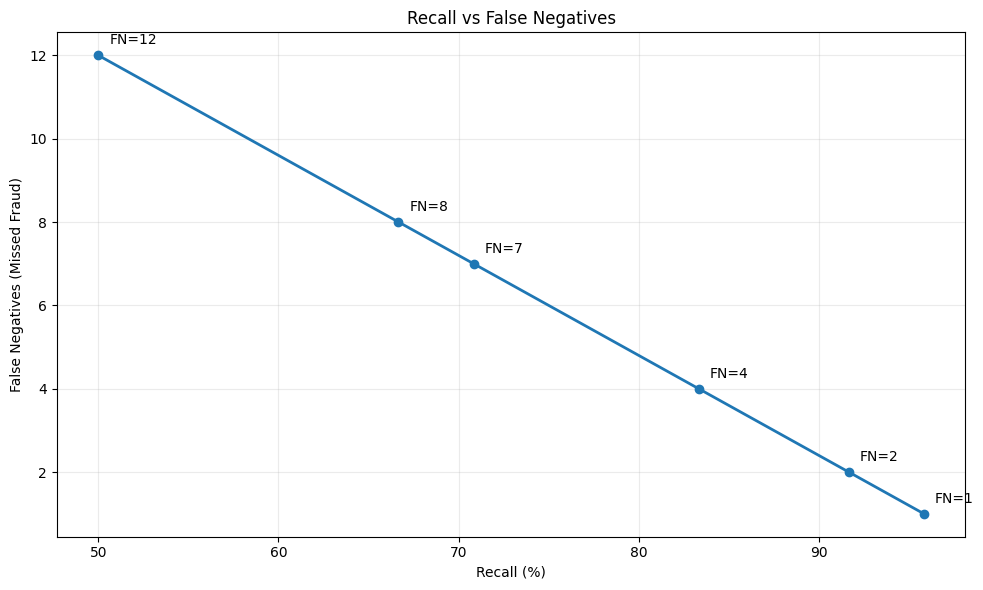

In [15]:
# ============================================================
# BLOCK 13 — RECALL VS FALSE NEGATIVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    target_results["recall"] * 100,
    target_results["FN"],
    marker="o",
    linewidth=2
)

for _, row in target_results.iterrows():

    plt.annotate(
        f"FN={int(row['FN'])}",
        (
            row["recall"] * 100,
            row["FN"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Recall (%)")
plt.ylabel("False Negatives (Missed Fraud)")
plt.title("Recall vs False Negatives")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "recall_vs_false_negatives.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

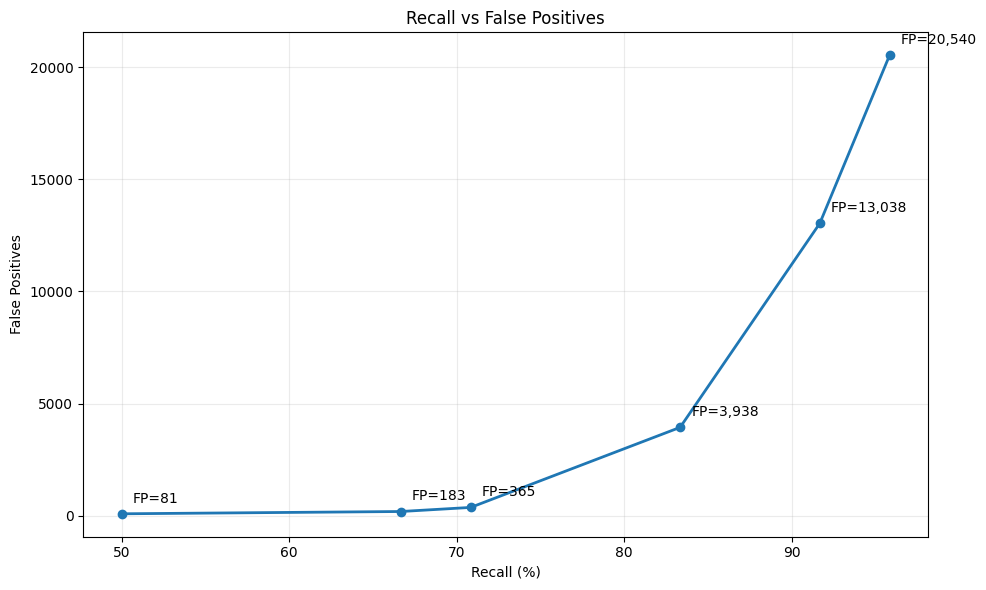

In [16]:
# ============================================================
# BLOCK 14 — RECALL VS FALSE POSITIVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    target_results["recall"] * 100,
    target_results["FP"],
    marker="o",
    linewidth=2
)

for _, row in target_results.iterrows():

    plt.annotate(
        f"FP={int(row['FP']):,}",
        (
            row["recall"] * 100,
            row["FP"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Recall (%)")
plt.ylabel("False Positives")
plt.title("Recall vs False Positives")

plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "recall_vs_false_positives.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()